# Avaliação Prática de M&V

Este notebook **reproduz em Python (statsmodels)** os cálculos da memória de cálculo em Excel
(`M&V_Memoria_de_Calculo.xlsx`, na pasta `memoria_de_calculo/`; o ajuste principal foi feito no Excel com a função `PROJ.LIN`) e gera as figuras do relatório. Os dados são lidos das abas `Ano 0 - Linha de Base` e `Ano 1 - Pós-AEE` da própria planilha. Serve como validação cruzada independente:
a seção 8 compara os resultados com os valores do Excel.

Roteiro: 1) dados · 2) Parte I – correlação e seleção · 3) dependência Temp–UR · 4) Parte II – regressão linear múltipla (modelo completo) e eliminação regressiva ·
5) validação · 6) Parte III – economia evitada · 7) Parte IV – ANR · 8) conferência com o Excel · 9) figuras.

In [1]:
import numpy as np, pandas as pd, statsmodels.api as sm
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

ALFA = 0.05                    # nível de significância (mesma premissa do Excel, célula nomeada 'alfa')
LIMIARES = (0.7, 0.5, 0.3)     # |r|: forte, moderada, fraca
SEMANA_ANR, CARGA_ANR = 30, 15 # premissa do ANR (extrusora: a partir da semana 30, 15 MWh/semana)

NOME = 'M&V_Memoria_de_Calculo.xlsx'   # abas 'Ano 0 - Linha de Base' e 'Ano 1 - Pós-AEE' (colunas B:J, cabeçalho na linha 5)
ARQ = next((b/s/NOME for b in (Path('..'), Path('.')) for s in ('memoria_de_calculo', 'Memória de Cálculo', '') if (b/s/NOME).exists()), None)
if ARQ is None: raise FileNotFoundError(f'{NOME} não encontrada (esperada em ../memoria_de_calculo/ ou na pasta do notebook)')
RAIZ = ARQ.parent.parent if ARQ.parent.name in ('memoria_de_calculo', 'Memória de Cálculo') else ARQ.parent
FIG = RAIZ/'figuras'; FIG.mkdir(exist_ok=True)
pd.options.display.float_format = '{:,.4f}'.format

## 1. Dados
Ano 0 = linha de base; Ano 1 = período de determinação (pós-AEE). Dados lidos das abas de mesmo nome da planilha do Excel. Colunas: semana, EE (MWh), P1…P5 (mil unid.), Temp (°C), UR (fração).

In [2]:
cols = ['S','EE','P1','P2','P3','P4','P5','T','UR']
d0 = pd.read_excel(ARQ, sheet_name='Ano 0 - Linha de Base', header=4, usecols='B:J').iloc[:52]; d0.columns = cols
d1 = pd.read_excel(ARQ, sheet_name='Ano 1 - Pós-AEE', header=4, usecols='B:J').iloc[:52]; d1.columns = cols
d0, d1 = d0.astype(float), d1.astype(float)
print(d0.shape, d1.shape, 'valores ausentes:', int(d0.isna().sum().sum()+d1.isna().sum().sum()))
d0.describe().T[['mean','std','min','max']]

(52, 9) (52, 9) valores ausentes: 0


,mean,std,min,max
S,26.5000,15.1548,1.0000,52.0000
EE,260.5385,15.1945,234.2000,292.2000
P1,22.7385,2.6869,17.4000,28.0000
P2,36.4346,2.8636,29.2000,42.1000
P3,82.2308,3.5293,75.5000,91.4000
P4,11.5500,1.0207,9.4000,13.7000
P5,144.9885,8.3900,128.5000,161.5000
T,22.3288,5.5227,14.6000,31.2000
UR,0.6086,0.0761,0.4800,0.7630


## 2. Parte I – Matriz de correlação e seleção de variáveis (questões 4.1a e 4.1b)
**Pearson:** $r=\dfrac{\sum(x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum(x_i-\bar x)^2\,\sum(y_i-\bar y)^2}}$. A matriz é simétrica e a diagonal vale 1.
O teste de significância usa $t=r\sqrt{n-2}/\sqrt{1-r^2}$ com $n-2$ graus de liberdade; o *r* crítico é $t_c/\sqrt{n-2+t_c^2}$.

In [3]:
ordem = ['EE','P1','P2','P3','P4','P5','T','UR']
corr = d0[ordem].corr()
n = len(d0); gl = n-2
tc = stats.t.ppf(1-ALFA/2, gl); r_crit = tc/np.sqrt(gl+tc**2)
r = corr['EE'].drop('EE')
t = r*np.sqrt(gl)/np.sqrt(1-r**2); p_r = pd.Series(2*stats.t.sf(t.abs(), gl), index=r.index)
classe = r.abs().map(lambda v: 'Forte' if v>=LIMIARES[0] else 'Moderada' if v>=LIMIARES[1] else 'Fraca' if v>=LIMIARES[2] else 'Muito fraca')
tab_r = pd.DataFrame({'r':r,'|r|':r.abs(),'t':t,'p-valor':p_r,'Classe':classe,'Significativa':np.where(p_r<ALFA,'Sim','Não')})
print(f'r crítico (n={n}, α={ALFA}) = {r_crit:.4f}')
display(corr.round(2)); tab_r.sort_values('|r|', ascending=False)

r crítico (n=52, α=0.05) = 0.2732


,EE,P1,P2,P3,P4,P5,T,UR
EE,1.0000,0.5600,0.5700,0.2100,0.1300,0.4000,0.8600,0.7800
P1,0.5600,1.0000,-0.0700,0.0100,0.1800,0.3500,0.1800,0.2000
P2,0.5700,-0.0700,1.0000,0.0300,0.0300,-0.0100,0.5400,0.4200
P3,0.2100,0.0100,0.0300,1.0000,0.0300,0.0900,0.3200,0.3500
P4,0.1300,0.1800,0.0300,0.0300,1.0000,0.0200,0.0400,0.0700
P5,0.4000,0.3500,-0.0100,0.0900,0.0200,1.0000,0.3800,0.4200
T,0.8600,0.1800,0.5400,0.3200,0.0400,0.3800,1.0000,0.9300
UR,0.7800,0.2000,0.4200,0.3500,0.0700,0.4200,0.9300,1.0000


,r,|r|,t,p-valor,Classe,Significativa
T,0.8587,0.8587,11.8492,0.0000,Forte,Sim
UR,0.7767,0.7767,8.7195,0.0000,Forte,Sim
P2,0.5709,0.5709,4.9172,0.0000,Moderada,Sim
P1,0.5570,0.5570,4.7426,0.0000,Moderada,Sim
P5,0.3976,0.3976,3.0639,0.0035,Fraca,Sim
P3,0.2068,0.2068,1.4946,0.1413,Muito fraca,Não
P4,0.1335,0.1335,0.9522,0.3456,Muito fraca,Não


### 2.1 Classificação do impacto (4.1b)
Três critérios: (1) correlação significativa; (2) efeito parcial significativo (p < α na regressão com as 7 variáveis); (3) peso físico no processo (premissa de engenharia, a partir do dicionário de dados do enunciado).
*Direto* = (2) e (3). *Indireto* = correlação significativa, mas colinear (|r| ≥ limiar forte) com outra variável e sem efeito parcial. Caso contrário, *sem efeito próprio*.

In [4]:
regs = ['P1','P2','P3','P4','P5','T','UR']
mf = sm.OLS(d0.EE, sm.add_constant(d0[regs])).fit()          # modelo completo, 7 variáveis (4.2a)
peso = {'P1':'Alto','P2':'Médio','P3':'Baixo','P4':'Baixo','P5':'Baixo','T':'Alto','UR':'Médio'}   # premissa
linhas = []
for v in regs:
    outros = corr.loc[v, [x for x in regs if x != v]].abs()
    p_par = mf.pvalues[v]
    if peso[v] != 'Baixo' and p_par < ALFA: cls = 'Direto'
    elif p_par >= ALFA and p_r[v] < ALFA and outros.max() >= LIMIARES[0]: cls = f'Indireto (via {outros.idxmax()})'
    else: cls = 'Sem efeito próprio'
    linhas.append([v, r[v], classe[v], p_r[v] < ALFA, outros.max(), outros.idxmax(), p_par, peso[v], cls, 'Manter' if cls=='Direto' else 'Descartar'])
sel = pd.DataFrame(linhas, columns=['Variável','r com EE','Classe |r|','Corr. signif.','Maior |r| outro regressor','Colinear com','p parcial','Peso físico','Classificação','Decisão']).set_index('Variável')
sel

,r com EE,Classe |r|,Corr. signif.,Maior |r| outro regressor,Colinear com,p parcial,Peso físico,Classificação,Decisão
Variável,,,,,,,,,
P1,0.5570,Moderada,True,0.3459,P5,0.0000,Alto,Direto,Manter
P2,0.5709,Moderada,True,0.5365,T,0.0000,Médio,Direto,Manter
P3,0.2068,Muito fraca,False,0.3521,UR,0.8683,Baixo,Sem efeito próprio,Descartar
P4,0.1335,Muito fraca,False,0.1783,P1,0.5571,Baixo,Sem efeito próprio,Descartar
P5,0.3976,Fraca,True,0.4212,UR,0.9616,Baixo,Sem efeito próprio,Descartar
T,0.8587,Forte,True,0.9255,UR,0.0000,Alto,Direto,Manter
UR,0.7767,Forte,True,0.9255,T,0.3502,Médio,Indireto (via T),Descartar


## 3. Dependência entre temperatura e umidade (4.1d)
Regressão auxiliar $UR=a+b\,T$; $VIF=1/(1-R^2)$; compara-se (A) P1,P2,Temp, (B) P1,P2,UR e (C) P1,P2,Temp + UR⊥, em que UR⊥ é o resíduo da regressão auxiliar (parte da UR **não** explicada pela temperatura).

In [5]:
aux = sm.OLS(d0.UR, sm.add_constant(d0['T'])).fit()
print(f"UR = {aux.params['const']:.4f} + {aux.params['T']:.5f}·T | r = {np.sqrt(aux.rsquared):.4f} | R² = {aux.rsquared:.4f} | erro-padrão = {np.sqrt(aux.scale):.4f} | VIF par-a-par = {1/(1-aux.rsquared):.2f}")
d0['UR_perp'] = aux.resid
def ajusta(V): return sm.OLS(d0.EE, sm.add_constant(d0[V])).fit()
mods = {'A  P1, P2, Temp':ajusta(['P1','P2','T']), 'B  P1, P2, UR':ajusta(['P1','P2','UR']), 'C  P1, P2, Temp + UR⊥':ajusta(['P1','P2','T','UR_perp'])}
pd.DataFrame({k:{'R²':m.rsquared,'R² aj.':m.rsquared_adj,'RMSE (MWh)':np.sqrt(m.scale),'CV(RMSE)':np.sqrt(m.scale)/d0.EE.mean()} for k,m in mods.items()}).T
print('p-valor de UR⊥ no modelo C:', round(mods['C  P1, P2, Temp + UR⊥'].pvalues['UR_perp'],4))

UR = 0.3239 + 0.01275·T | r = 0.9255 | R² = 0.8565 | erro-padrão = 0.0291 | VIF par-a-par = 6.97
p-valor de UR⊥ no modelo C: 0.3394


## 4. Parte II – Regressão linear múltipla: modelo completo e eliminação regressiva (4.2a, 4.2b)
Remove-se, a cada passo, a variável de maior p-valor acima de α, até que todas sejam significativas.

In [6]:
print(mf.summary().tables[1])
print(f'R²={mf.rsquared:.4f}  R² aj.={mf.rsquared_adj:.4f}  RMSE={np.sqrt(mf.scale):.3f}  F={mf.fvalue:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.8647     20.030      5.834      0.000      76.497     157.232
P1             2.5874      0.204     12.693      0.000       2.177       2.998
P2             1.3549      0.225      6.033      0.000       0.902       1.808
P3            -0.0257      0.154     -0.167      0.868      -0.336       0.285
P4             0.2949      0.498      0.592      0.557      -0.710       1.299
P5             0.0034      0.070      0.048      0.962      -0.138       0.145
T              1.9750      0.266      7.421      0.000       1.439       2.511
UR           -17.1126     18.122     -0.944      0.350     -53.635      19.410
R²=0.9527  R² aj.=0.9451  RMSE=3.559  F=126.5


In [7]:
V = list(regs); passos = []
while True:
    m = sm.OLS(d0.EE, sm.add_constant(d0[V])).fit()
    pmax = m.pvalues[V].max(); pior = m.pvalues[V].idxmax()
    passos.append([len(V), pior if pmax >= ALFA else '—', pmax, m.rsquared_adj, np.sqrt(m.scale)])
    if pmax < ALFA: break
    V.remove(pior)
print('Variáveis finais:', V)
pd.DataFrame(passos, columns=['nº var.','Variável removida','p-valor (maior)','R² aj.','RMSE (MWh)'])

Variáveis finais: ['P1', 'P2', 'T']


,nº var.,Variável removida,p-valor (maior),R² aj.,RMSE (MWh)
0,7,P5,0.9616,0.9451,3.5592
1,6,P3,0.8629,0.9463,3.5195
2,5,P4,0.5524,0.9475,3.4822
3,4,UR,0.3394,0.9482,3.4584
4,3,—,0.0000,0.9483,3.4559


## 5. Modelo final e validação (4.2c)

In [8]:
mfin = sm.OLS(d0.EE, sm.add_constant(d0[V])).fit()
pred0 = mfin.predict(sm.add_constant(d0[V])); res = d0.EE - pred0
p_ = len(V)+1
rmse = np.sqrt(res.pow(2).sum()/(n-p_)); cv = rmse/d0.EE.mean()
vifs = [variance_inflation_factor(sm.add_constant(d0[V]).values, i) for i in range(1, p_)]
print(mfin.summary().tables[1])
val = pd.DataFrame({'Obtido':[mfin.rsquared, cv, mfin.tvalues[V].abs().min(), mfin.fvalue, durbin_watson(res), max(vifs)],
                    'Critério':['> 0,75','< 15 %','> 2,0','p < 0,001','≈ 2','< 5']},
                   index=['R²','CV(RMSE)','|t| mínimo','Estatística F','Durbin-Watson','VIF máx.'])
print('Shapiro-Wilk dos resíduos: p =', round(stats.shapiro(res).pvalue,3))
print('EE_LB =', ' + '.join([f"{mfin.params['const']:.4f}"]+[f"{mfin.params[v]:.4f}·{v}" for v in V]))
val

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.0055      8.208     13.525      0.000      94.503     127.508
P1             2.6083      0.187     13.931      0.000       2.232       2.985
P2             1.4110      0.205      6.894      0.000       0.999       1.822
T              1.7384      0.108     16.149      0.000       1.522       1.955
Shapiro-Wilk dos resíduos: p = 0.241
EE_LB = 111.0055 + 2.6083·P1 + 1.4110·P2 + 1.7384·T


,Obtido,Critério
R²,0.9513,"> 0,75"
CV(RMSE),0.0133,< 15 %
|t| mínimo,6.8941,"> 2,0"
Estatística F,312.6245,"p < 0,001"
Durbin-Watson,1.6678,≈ 2
VIF máx.,1.5092,< 5


## 6. Parte III – Economia evitada no Ano 1 (4.3)
Linha de base ajustada = modelo do Ano 0 aplicado às condições (produção e clima) do Ano 1; economia = LB ajustada − consumo medido.

In [9]:
lb = mfin.predict(sm.add_constant(d1[V])); eco = lb - d1.EE
tot = pd.Series({'Consumo medido Ano 1 (MWh)':d1.EE.sum(),'LB ajustada (MWh)':lb.sum(),'Economia evitada (MWh)':eco.sum(),
                 'Redução vs. LB ajustada':eco.sum()/lb.sum(),'Economia média (MWh/sem)':eco.mean(),'Mín. semanal':eco.min(),'Máx. semanal':eco.max(),
                 'Redução bruta Ano1 vs Ano0':1-d1.EE.sum()/d0.EE.sum()}); tot

Consumo medido Ano 1 (MWh)   10,735.8000
LB ajustada (MWh)            13,619.2087
Economia evitada (MWh)        2,883.4087
Redução vs. LB ajustada           0.2117
Economia média (MWh/sem)         55.4502
Mín. semanal                     50.0687
Máx. semanal                     64.7771
Redução bruta Ano1 vs Ano0        0.2076
dtype: float64

## 7. Parte IV – Ajuste não de rotina (4.4)
**Premissa:** os dados não contêm a extrusora; assume-se que o consumo real das semanas ≥ 30 seria o registrado **+ 15 MWh/semana**. Sem ANR a economia é subestimada; o ANR eleva a linha de base: $EE_{LB,aj,ANR}(s)=EE_{LB,aj}(s)+15\cdot u(s-30)$.

In [10]:
deg = np.where(d1.S >= SEMANA_ANR, CARGA_ANR, 0)
med = d1.EE + deg; lb_anr = lb + deg
anr = pd.Series({'ANR total (MWh)':deg.sum(),'Economia SEM ANR (MWh)':(lb-med).sum(),'Redução SEM ANR':(lb-med).sum()/lb.sum(),
                 'Economia COM ANR (MWh)':(lb_anr-med).sum(),'Redução COM ANR':(lb_anr-med).sum()/lb_anr.sum(),
                 'Alternativa (só eleva a LB; MWh)':(lb_anr-d1.EE).sum()}); anr

ANR total (MWh)                      345.0000
Economia SEM ANR (MWh)             2,538.4087
Redução SEM ANR                        0.1864
Economia COM ANR (MWh)             2,883.4087
Redução COM ANR                        0.2065
Alternativa (só eleva a LB; MWh)   3,228.4087
dtype: float64

## 8. Conferência com o Excel
Valores da aba *Resumo* do Excel (recalculado no LibreOffice). A tolerância é de 1e-6 (relativa).

In [11]:
excel = {'r(Temp,EE)':0.858720836211175,'R² UR~Temp':0.856499304930255,'p(UR⊥)':0.339387238280284,
 'β0':111.005546832351,'β1 P1':2.60826539346306,'β2 P2':1.41098020511784,'β3 Temp':1.73839933414071,
 'R²':0.951312206080073,'R² aj.':0.948269218960078,'CV(RMSE)':0.0132644612946526,
 'Economia Ano 1':2883.40869595074,'Redução':0.211716316294355,
 'Economia sem ANR':2538.40869595074,'Economia com ANR':2883.40869595074,'Redução com ANR':0.206485649042674}
py = {'r(Temp,EE)':r['T'],'R² UR~Temp':aux.rsquared,'p(UR⊥)':mods['C  P1, P2, Temp + UR⊥'].pvalues['UR_perp'],
 'β0':mfin.params['const'],'β1 P1':mfin.params['P1'],'β2 P2':mfin.params['P2'],'β3 Temp':mfin.params['T'],
 'R²':mfin.rsquared,'R² aj.':mfin.rsquared_adj,'CV(RMSE)':cv,'Economia Ano 1':eco.sum(),'Redução':eco.sum()/lb.sum(),
 'Economia sem ANR':(lb-med).sum(),'Economia com ANR':(lb_anr-med).sum(),'Redução com ANR':(lb_anr-med).sum()/lb_anr.sum()}
conf = pd.DataFrame({'Excel':excel,'Python':py}); conf['Dif. relativa'] = (conf.Python-conf.Excel).abs()/conf.Excel.abs()
conf['OK'] = conf['Dif. relativa'] < 1e-6
assert V == ['P1','P2','T'], 'variáveis finais diferem do Excel'
assert conf.OK.all(), conf[~conf.OK]
conf

,Excel,Python,Dif. relativa,OK
"r(Temp,EE)",0.8587,0.8587,0.0000,True
R² UR~Temp,0.8565,0.8565,0.0000,True
p(UR⊥),0.3394,0.3394,0.0000,True
β0,111.0055,111.0055,0.0000,True
β1 P1,2.6083,2.6083,0.0000,True
β2 P2,1.4110,1.4110,0.0000,True
β3 Temp,1.7384,1.7384,0.0000,True
R²,0.9513,0.9513,0.0000,True
R² aj.,0.9483,0.9483,0.0000,True
CV(RMSE),0.0133,0.0133,0.0000,True


### 8.1 Conferência da Tabela III e da parcimônia
Compara a eliminação regressiva (Tabela III do relatório) com a aba *4.2b* e reproduz os números usados na seção III.D (aba *4.1c*): graus de liberdade e observações por parâmetro (regra prática: ≥ 10 por parâmetro, conforme a aba *4.1c*).

In [12]:
# Tabela III do relatório (eliminação regressiva) e números da seção III.D (parcimônia) – valores das abas 4.2b e 4.1c do Excel
excel_t3 = pd.DataFrame({'Variável removida': ['P5', 'P3', 'P4', 'UR', '—'],
    'p-valor (maior)': [0.961551804090742, 0.862917666420504, 0.552369637609378, 0.339387238280284, 1.06881579407312e-08],
    'R² aj.': [0.945130703010472, 0.94634715475314, 0.947478349102946, 0.948195399685711, 0.948269218960078],
    'RMSE (MWh)': [3.55919384186837, 3.51951906685193, 3.48221937613064, 3.45836722775748, 3.45590233884526]}, index=[7,6,5,4,3])
py_t3 = pd.DataFrame(passos, columns=['nº var.','Variável removida','p-valor (maior)','R² aj.','RMSE (MWh)']).set_index('nº var.')
assert (excel_t3['Variável removida'] == py_t3['Variável removida']).all(), 'ordem de remoção difere do Excel'
dif_t3 = {c: (py_t3[c]-excel_t3[c]).abs().max() for c in ['p-valor (maior)','R² aj.','RMSE (MWh)']}
assert all(v < 1e-6 for v in dif_t3.values()), dif_t3

# Parcimônia: graus de liberdade residuais e observações por parâmetro (aba 4.1c)
parc = pd.DataFrame({'M1 (7 variáveis)': [mf.df_resid, n/len(mf.params), mf.rsquared_adj, np.sqrt(mf.scale)],
                     'M5 (modelo final)': [mfin.df_resid, n/len(mfin.params), mfin.rsquared_adj, np.sqrt(mfin.scale)]},
                    index=['gl residuais (n−k−1)','observações por parâmetro n/(k+1)','R² ajustado','RMSE (MWh)'])
assert (mf.df_resid, mfin.df_resid) == (44, 48) and abs(parc.iloc[1,0]-6.5) < 1e-9 and abs(parc.iloc[1,1]-13) < 1e-9
print('Tabela III confere com o Excel (dif. máx.):', {k: f'{v:.1e}' for k, v in dif_t3.items()})
parc

Tabela III confere com o Excel (dif. máx.): {'p-valor (maior)': '7.1e-14', 'R² aj.': '5.6e-16', 'RMSE (MWh)': '4.4e-15'}


,M1 (7 variáveis),M5 (modelo final)
gl residuais (n−k−1),44.0000,48.0000
observações por parâmetro n/(k+1),6.5000,13.0000
R² ajustado,0.9451,0.9483
RMSE (MWh),3.5592,3.4559


## 9. Figuras do relatório
Geradas em `figuras/` (300 dpi), na mesma formatação do relatório.

In [13]:
plt.rcParams.update({'font.family':'serif','font.serif':['Times New Roman','Liberation Serif','DejaVu Serif'],'font.size':8,'axes.grid':True,'grid.alpha':.3,'axes.axisbelow':True})
W = 3.45; nm = {'EE':'EE','P1':'P1','P2':'P2','P3':'P3','P4':'P4','P5':'P5','T':'Temp','UR':'UR'}
keep = {'P1','P2','T'}
soft = LinearSegmentedColormap.from_list('soft',['#9DC3E6','#FFFFFF','#F4B183'])
d0 = d0.drop(columns='UR_perp')
pt = lambda x, d=2: f'{x:.{d}f}'.replace('.',',')

**Fig. 1 – matriz de Pearson (triângulo inferior)**

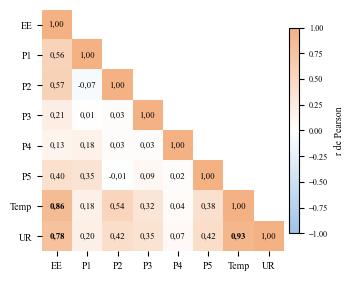

In [14]:
order=['EE','P1','P2','P3','P4','P5','T','UR'];C=d0[order].corr().values
fig,ax=plt.subplots(figsize=(W,3.1))
M=np.ma.masked_where(np.triu(np.ones_like(C,bool),1),C)
im=ax.imshow(M,cmap=soft,vmin=-1,vmax=1);ax.grid(False)
ax.set_xticks(range(8));ax.set_xticklabels([nm[v] for v in order],fontsize=7);ax.set_yticks(range(8));ax.set_yticklabels([nm[v] for v in order],fontsize=7)
for i in range(8):
    for j in range(i+1):
        ax.text(j,i,f'{C[i,j]:.2f}'.replace('.',','),ha='center',va='center',fontsize=6.3,fontweight='bold' if (i==0 or abs(C[i,j])>=.7) and i!=j else 'normal')
for s in ax.spines.values(): s.set_visible(False)
cb=plt.colorbar(im,fraction=.04,pad=.02);cb.set_label('r de Pearson',fontsize=7);cb.ax.tick_params(labelsize=6)
plt.tight_layout();plt.savefig(''+str(FIG)+'/f01_matriz.png',dpi=300);plt.show()

**Fig. 2 – r de cada variável com o consumo**

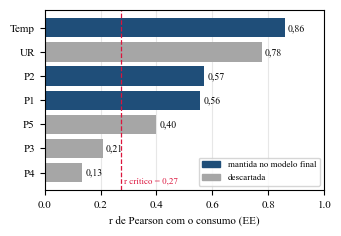

In [15]:
# 2 barras r com EE
rc=r_crit
rs=r.reindex(r.abs().sort_values().index)
fig,ax=plt.subplots(figsize=(W,2.4));keep={'P1','P2','T'}
ax.barh([nm[v] for v in rs.index],rs.values,color=['#1F4E79' if v in keep else '#A6A6A6' for v in rs.index])
ax.axvline(rc,color='crimson',ls='--',lw=.9);ax.text(rc+.01,-.45,f'r crítico = {rc:.2f}'.replace('.',','),color='crimson',fontsize=6.5)
for i,v in enumerate(rs.values): ax.text(v+.012,i,f'{v:.2f}'.replace('.',','),va='center',fontsize=7)
ax.set_xlim(0,1);ax.set_xlabel('r de Pearson com o consumo (EE)');ax.grid(axis='y',alpha=0)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1F4E79',label='mantida no modelo final'),Patch(color='#A6A6A6',label='descartada')],fontsize=6.5,loc='lower right')
plt.tight_layout();plt.savefig(''+str(FIG)+'/f02_barras_r.png',dpi=300);plt.show()

**Fig. 3 – dispersões EE × variável**

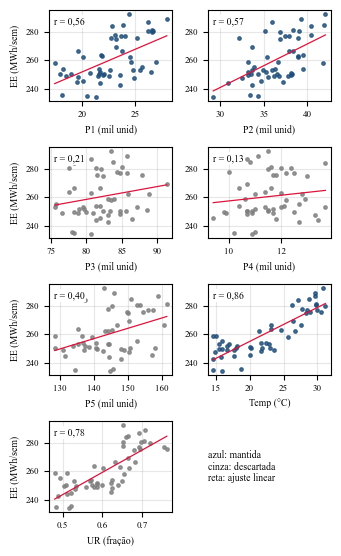

In [16]:
# 3 dispersões
fig,axs=plt.subplots(4,2,figsize=(W,5.6));axs=axs.ravel()
for ax,v in zip(axs,order[1:]):
    ax.scatter(d0[v],d0.EE,s=6,color='#1F4E79' if v in keep else '#7F7F7F',alpha=.8)
    a,b=np.polyfit(d0[v],d0.EE,1);xs=np.array([d0[v].min(),d0[v].max()]);ax.plot(xs,a*xs+b,color='crimson',lw=.9)
    ax.text(.04,.84,f'r = {r[v]:.2f}'.replace('.',','),transform=ax.transAxes,fontsize=7,bbox=dict(fc='white',ec='none',pad=1))
    lab={'T':'Temp (°C)','UR':'UR (fração)'}.get(v,f'{v} (mil unid)');ax.set_xlabel(lab,fontsize=7);ax.tick_params(labelsize=6.5)
    if v in('P1','P3','P5','UR'): ax.set_ylabel('EE (MWh/sem)',fontsize=7)
axs[-1].axis('off');axs[-1].text(0,.5,'azul: mantida\ncinza: descartada\nreta: ajuste linear',fontsize=7,va='center')
plt.tight_layout();plt.savefig(''+str(FIG)+'/f03_dispersoes.png',dpi=300);plt.show()

**Fig. 4 – UR × Temp**

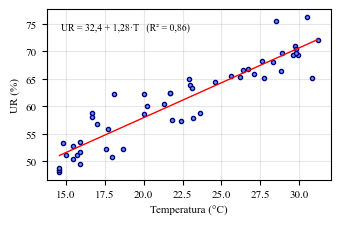

In [17]:
# 4 UR x T
a,b=np.polyfit(d0['T'],d0.UR,1);r2=np.corrcoef(d0['T'],d0.UR)[0,1]**2
fig,ax=plt.subplots(figsize=(W,2.3));ax.scatter(d0['T'],d0.UR*100,s=9,edgecolor='navy',facecolor='cornflowerblue')
xs=np.linspace(d0['T'].min(),d0['T'].max(),10);ax.plot(xs,(a*xs+b)*100,'r-',lw=1)
ax.set_xlabel('Temperatura (°C)');ax.set_ylabel('UR (%)');ax.text(.05,.88,f'UR = {b*100:.1f} + {a*100:.2f}·T   (R² = {r2:.2f})'.replace('.',','),transform=ax.transAxes,fontsize=7)
plt.tight_layout();plt.savefig(''+str(FIG)+'/f04_ur_temp.png',dpi=300);plt.show()

**Fig. 5 – coeficientes padronizados**

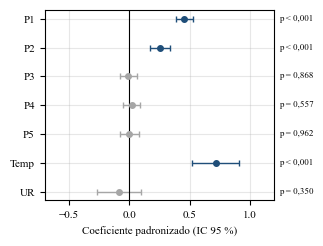

In [18]:
# 5 forest coef padronizados (modelo completo)
X=d0[['P1','P2','P3','P4','P5','T','UR']];mf=sm.OLS(d0.EE,sm.add_constant(X)).fit()
sc=X.std().values/d0.EE.std();bs=mf.params[1:].values*sc;ci=mf.conf_int().iloc[1:].values*sc[:,None]
fig,ax=plt.subplots(figsize=(W,2.5));ys=np.arange(7)[::-1]
for y,b_,(lo,hi),v,p in zip(ys,bs,ci,X.columns,mf.pvalues[1:]):
    sig=p<.05;ax.errorbar(b_,y,xerr=[[b_-lo],[hi-b_]],fmt='o',color='#1F4E79' if sig else '#A6A6A6',capsize=2.5,ms=4,lw=1)
    ax.text(1.02,y,f'p = {p:.3f}'.replace('.',',') if p>=.001 else 'p < 0,001',transform=ax.get_yaxis_transform(),va='center',fontsize=6.5)
ax.axvline(0,color='k',lw=.8);ax.set_yticks(ys);ax.set_yticklabels([nm[v] for v in X.columns]);ax.set_xlabel('Coeficiente padronizado (IC 95 %)');ax.set_xlim(-.7,1.2)
plt.tight_layout();plt.subplots_adjust(right=.8);plt.savefig(''+str(FIG)+'/f05_forest.png',dpi=300);plt.show()

**Figs. 6 e 7 – ajuste e resíduos**

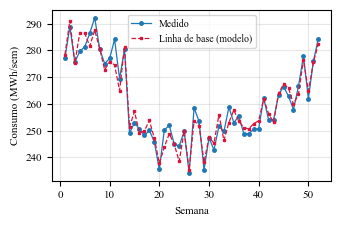

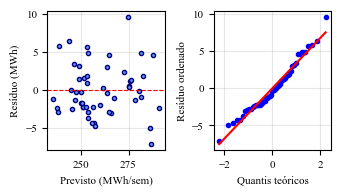

In [19]:
# 6 ajuste, 7 resíduos
fig,ax=plt.subplots(figsize=(W,2.3));ax.plot(d0.S,d0.EE,'o-',ms=2.5,lw=.9,label='Medido');ax.plot(d0.S,pred0,'s--',ms=2,lw=.9,color='crimson',label='Linha de base (modelo)')
ax.set_xlabel('Semana');ax.set_ylabel('Consumo (MWh/sem)');ax.legend(fontsize=7);plt.tight_layout();plt.savefig(''+str(FIG)+'/f06_ajuste.png',dpi=300);plt.show()
fig,ax=plt.subplots(1,2,figsize=(W,2.0))
ax[0].scatter(pred0,res,s=9,edgecolor='navy',facecolor='cornflowerblue');ax[0].axhline(0,color='r',ls='--',lw=.8);ax[0].set_xlabel('Previsto (MWh/sem)');ax[0].set_ylabel('Resíduo (MWh)')
stats.probplot(res,plot=ax[1]);ax[1].set_title('');ax[1].get_lines()[0].set_markersize(3);ax[1].set_xlabel('Quantis teóricos');ax[1].set_ylabel('Resíduo ordenado')
plt.tight_layout();plt.savefig(''+str(FIG)+'/f07_residuos.png',dpi=300);plt.show()

**Fig. 8 – economia semanal**

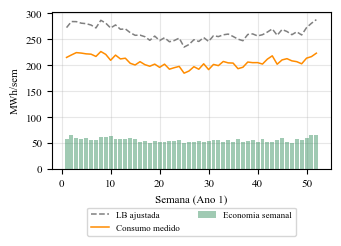

In [20]:
# 8 economia semanal
fig,ax=plt.subplots(figsize=(W,2.6));ax.bar(d1.S,eco,color='seagreen',alpha=.45,label='Economia semanal')
ax.plot(d1.S,lb,'--',color='gray',lw=1.1,label='LB ajustada');ax.plot(d1.S,d1.EE,'-',color='darkorange',lw=1.1,label='Consumo medido')
ax.set_xlabel('Semana (Ano 1)');ax.set_ylabel('MWh/sem');ax.legend(ncol=2,fontsize=6.5,loc='upper center',bbox_to_anchor=(.5,-.22));plt.tight_layout();plt.savefig(''+str(FIG)+'/f08_economia.png',dpi=300);plt.show()

**Fig. 9 – economia acumulada**

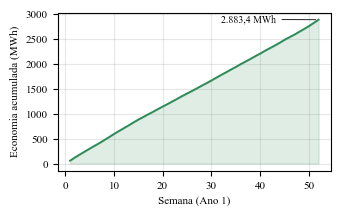

In [21]:
# 9 economia acumulada
fig,ax=plt.subplots(figsize=(W,2.2));cum=eco.cumsum();ax.plot(d1.S,cum,color='seagreen',lw=1.4);ax.fill_between(d1.S,cum,color='seagreen',alpha=.15)
ax.annotate(f'{cum.iloc[-1]:,.1f} MWh'.replace(',','X').replace('.',',').replace('X','.'),(52,cum.iloc[-1]),xytext=(-70,-2),textcoords='offset points',fontsize=7,arrowprops=dict(arrowstyle='-',lw=.6))
ax.set_xlabel('Semana (Ano 1)');ax.set_ylabel('Economia acumulada (MWh)');plt.tight_layout();plt.savefig(''+str(FIG)+'/f09_acumulada.png',dpi=300);plt.show()

**Fig. 10 – ANR**

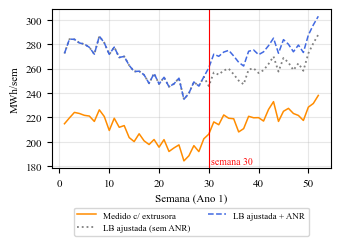

In [22]:
# 10 ANR
meas=d1.EE+np.where(d1.S>=30,15,0);lba=lb+np.where(d1.S>=30,15,0)
fig,ax=plt.subplots(figsize=(W,2.6));ax.plot(d1.S,meas,'-',color='darkorange',lw=1.1,label='Medido c/ extrusora');ax.plot(d1.S,lb,':',color='gray',lw=1.3,label='LB ajustada (sem ANR)');ax.plot(d1.S,lba,'--',color='royalblue',lw=1.1,label='LB ajustada + ANR')
ax.axvline(30,color='r',lw=.8);ax.text(30.5,ax.get_ylim()[0]+3,'semana 30',color='r',fontsize=7)
ax.set_xlabel('Semana (Ano 1)');ax.set_ylabel('MWh/sem');ax.legend(ncol=2,fontsize=6.5,loc='upper center',bbox_to_anchor=(.5,-.22));plt.tight_layout();plt.savefig(''+str(FIG)+'/f10_anr.png',dpi=300);plt.show()

---
**Reprodutibilidade:** instale as dependências (`numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib`, `openpyxl`) e execute *Run All* (mantenha as pastas `Notebook/`, `memoria_de_calculo/` e `figuras/` lado a lado). O notebook falha (`assert`) se algum resultado divergir do Excel.